In [6]:

import pandas as pd
import numpy as np

# Load the five-stock dataset saved on Day 6
prices = pd.read_csv(
    "five_stock_prices.csv",
    index_col=0,
    parse_dates=True
)

# Keep the stocks in the correct order
tickers = ["AAPL", "MSFT", "JPM", "GS", "BLK"]
prices = prices[tickers].sort_index()

# Check that the dataset is usable
assert not prices.empty, "Price data is empty"
print("Missing values by stock:")
print(prices.isna().sum())

print("\nRows containing missing values:")
display(prices[prices.isna().any(axis=1)].head(10))

print("Trading days:", len(prices))
print("Stocks:", list(prices.columns))

display(prices.head())

Missing values by stock:
AAPL    1
MSFT    1
JPM     1
GS      1
BLK     1
dtype: int64

Rows containing missing values:


,AAPL,MSFT,JPM,GS,BLK
Date,,,,,
2026-09-22,NaN,NaN,NaN,NaN,NaN


Trading days: 251
Stocks: ['AAPL', 'MSFT', 'JPM', 'GS', 'BLK']


,AAPL,MSFT,JPM,GS,BLK
Date,,,,,
2025-09-23,253.493591,505.074463,306.869354,790.766968,1108.070068
2025-09-24,251.381409,505.986908,307.536621,777.144836,1104.378906
2025-09-25,255.924637,502.892334,307.566071,779.429932,1123.284790
2025-09-26,254.519806,507.286194,310.127045,787.030518,1132.253052
2025-09-29,253.493591,510.400513,309.764008,788.609436,1150.963501


In [1]:
print("Day 7 kernel is working!")

Day 7 kernel is working!


In [7]:
print("Trading days:", len(prices))
print("Missing values:")
print(prices.isna().sum())

Trading days: 251
Missing values:
AAPL    1
MSFT    1
JPM     1
GS      1
BLK     1
dtype: int64


In [8]:

# Show every date containing at least one missing price
missing_rows = prices[prices.isna().any(axis=1)]

display(missing_rows)

,AAPL,MSFT,JPM,GS,BLK
Date,,,,,
2026-09-22,NaN,NaN,NaN,NaN,NaN


In [9]:

# Keep only dates with complete prices for all five stocks
prices = prices.dropna().copy()

# Verify the cleaned data
print("Trading days:", len(prices))
print("\nMissing values:")
print(prices.isna().sum())

assert not prices.empty, "No complete trading days remain"
assert not prices.isna().any().any(), "Missing values remain"

Trading days: 250

Missing values:
AAPL    0
MSFT    0
JPM     0
GS      0
BLK     0
dtype: int64


Final portfolio value: $11,527.32
Cumulative return: 15.27%


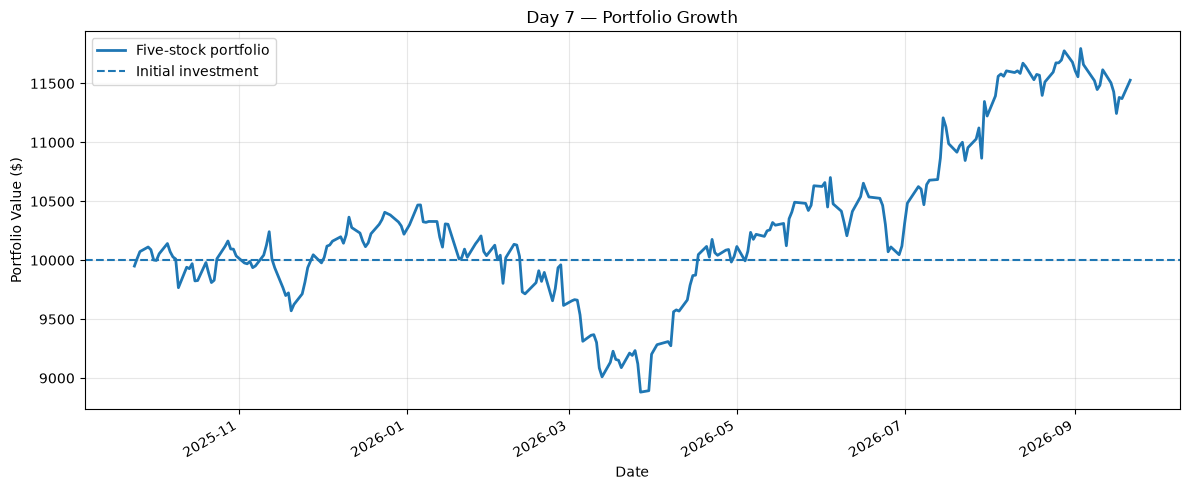

In [10]:

import numpy as np
import matplotlib.pyplot as plt

returns = prices.pct_change().dropna()

weights = np.array([0.20] * 5)
portfolio_returns = returns @ weights

initial_investment = 10000
portfolio_value = initial_investment * (
    1 + portfolio_returns
).cumprod()

print(f"Final portfolio value: ${portfolio_value.iloc[-1]:,.2f}")
print(f"Cumulative return: {(portfolio_value.iloc[-1] / initial_investment - 1):.2%}")

plt.figure(figsize=(12, 5))
portfolio_value.plot(label="Five-stock portfolio", linewidth=2)
plt.axhline(initial_investment, linestyle="--", label="Initial investment")
plt.title("Day 7 — Portfolio Growth")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:

# Include the initial $10,000 before the first return
starting_value = pd.Series(
    [initial_investment],
    index=[prices.index[0]]
)

equity_curve = pd.concat([
    starting_value,
    portfolio_value
])

# Calculate the previous highest portfolio value
running_peak = equity_curve.cummax()

# Calculate percentage decline from that peak
drawdown = equity_curve / running_peak - 1

maximum_drawdown = drawdown.min()

print(f"Maximum Drawdown: {maximum_drawdown:.2%}")

Maximum Drawdown: -15.17%


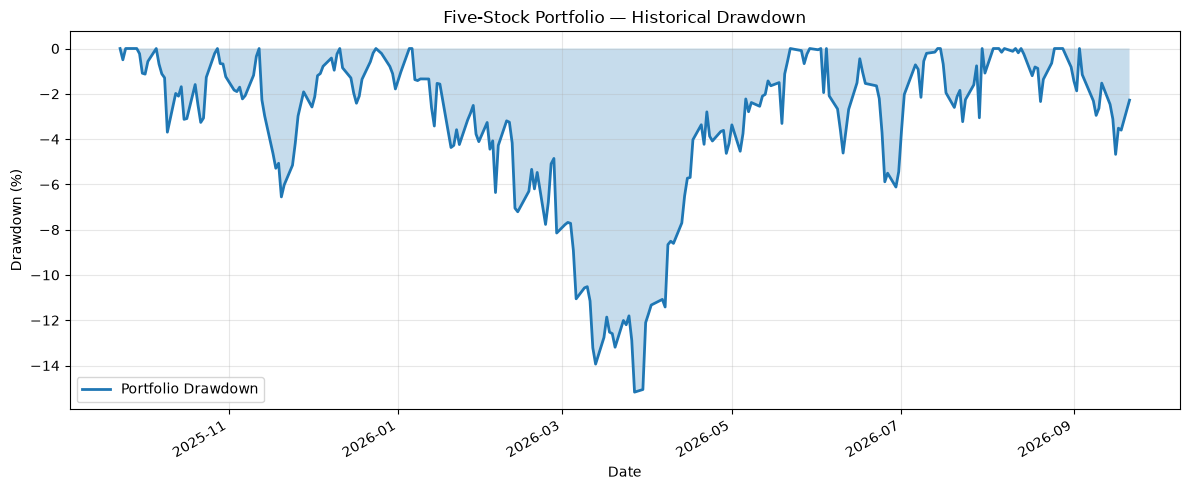

In [13]:

plt.figure(figsize=(12, 5))

(drawdown * 100).plot(
    linewidth=2,
    label="Portfolio Drawdown"
)

plt.fill_between(
    drawdown.index,
    drawdown.to_numpy() * 100,
    0,
    alpha=0.25
)

plt.title("Five-Stock Portfolio — Historical Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:

# Assumed annual risk-free rate; replace as appropriate
risk_free_rate = 0.04

annual_return = portfolio_returns.mean() * 252
annual_volatility = portfolio_returns.std() * np.sqrt(252)

sharpe_ratio = (
    (annual_return - risk_free_rate) / annual_volatility
    if annual_volatility > 0 else np.nan
)

cumulative_return = equity_curve.iloc[-1] / initial_investment - 1

summary = pd.DataFrame({
    "Metric": [
        "Initial Investment",
        "Final Portfolio Value",
        "Cumulative Return",
        "Annualized Average Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown"
    ],
    "Value": [
        f"${initial_investment:,.2f}",
        f"${equity_curve.iloc[-1]:,.2f}",
        f"{cumulative_return:.2%}",
        f"{annual_return:.2%}",
        f"{annual_volatility:.2%}",
        f"{sharpe_ratio:.2f}",
        f"{maximum_drawdown:.2%}"
    ]
})

display(summary)

,Metric,Value
0,Initial Investment,"$10,000.00"
1,Final Portfolio Value,"$11,527.32"
2,Cumulative Return,15.27%
3,Annualized Average Return,16.04%
4,Annualized Volatility,18.23%
5,Sharpe Ratio,0.66
6,Maximum Drawdown,-15.17%
